# getting sentinel 3 SLT data from `openeo`

This script downloads for the bounding box of a lake the Sentinel-3 LST L2 data using the `openeo` API with the CDSE backend. 
The script is largely based on the tutorial from openeo, see https://openeo.org/documentation/1.0/python/#installation
Additionally, you need a user acount for CDSE to login and access the data. 

### Attention: use the openeo2 environment to run this script!


In [3]:
import openeo
import pandas as pd
import geopandas as gpd
import numpy as np
import shapely as shp
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import cartopy

In [4]:
# connect to https://openeo.dataspace.copernicus.eu
connection = openeo.connect("https://openeofed.dataspace.copernicus.eu")

# this could instead also be another openeo backend provider (kind of a website or data portal where all the data collections are stored)
# all the backend provider can be found here: https://hub.openeo.org/
# example for GEE, which is also a backend for openeo:

# connection = openeo.connect("https://earthengine.openeo.org")

In [5]:
connection.list_collection_ids() # lists all the collections providd by the back-end
S3_LST_L2 = 'SENTINEL3_SLSTR_L2_LST' # there is indeed the dataset we need. I just save the name here

In [6]:
# this establishes the connection and then stores it so that I do not need to login everytime I run the notebook

connection.authenticate_oidc_device(
    provider_id="CDSE",
    store_refresh_token=True
)

# username: felician.heim@posteo.de
# password: SAR_now12calv#

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=DJFH-NHOJ 📋 to authenticate.

✅ Authorized successfully

<Connection to 'https://openeofed.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

# Explore dataset and get S3 L2 LST product
First I can explore the dataset I am interested in:


In [7]:
connection.describe_collection(S3_LST_L2) # product name had been saved earlier

{'cube:dimensions': {'bands': {'type': 'bands',
   'values': ['LST',
    'LST_uncertainty',
    'exception',
    'confidence_in',
    'sunAzimuthAngles',
    'sunZenithAngles',
    'viewAzimuthAngles',
    'viewZenithAngles']},
  't': {'extent': ['2016-04-17T11:33:13Z', None],
   'step': 'P2D',
   'type': 'temporal'},
  'x': {'axis': 'x',
   'extent': [-180, 180],
   'reference_system': 4326,
   'step': 0.008928571428571,
   'type': 'spatial'},
  'y': {'axis': 'y',
   'extent': [-90, 90],
   'reference_system': 4326,
   'step': 0.008928571428571,
   'type': 'spatial'}},
 'description': '*Experimental* Daily global Sentinel-3 land surface temperature at 1km resolution. Land surface temperature is defined as the effective radiometric temperature of the Earth\'s surface "skin" in the instrument field of view. Here, "skin" is referring to the top surface in bare soil conditions and to the effective emitting temperature of vegetation "canopies" as determined from a view of the top of a canopy.\n This product is derived from the SLSTR (Sea and Land Surface Temperature Radiometer) instrument on board the Sentinel-3 satellite.\n\n Multiple observations may be available per day, we recommend temporal aggregation to create daily composites. ',
 'experimental': True,
 'extent': {'spatial': {'bbox': [[0, 0, 0, 0]]},
  'temporal': {'interval': [[None, None]]}},
 'id': 'SENTINEL3_SLSTR_L2_LST',
 'keywords': ['COPERNICUS', 'ESA', 'Sentinel-3', 'SLSTR'],
 'license': 'proprietary',
 'links': [{'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.1/collections/SENTINEL3_SLSTR_L2_LST/queryables',
   'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
   'type': 'application/schema+json'},
  {'href': 'https://openeofed.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'root'},
  {'href': 'https://openeofed.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'parent'},
  {'href': 'https://openeofed.dataspace.copernicus.eu/openeo/1.2/collections/SENTINEL3_SLSTR_L2_LST',
   'rel': 'self'}],
 'stac_extensions': ['https://stac-extensions.github.io/datacube/v2.2.0/schema.json',
  'https://stac-extensions.github.io/eo/v1.1.0/schema.json'],
 'stac_version': '1.0.0',
 'summaries': {'bands': [{'eo:common_name': 'surface_temperature',
    'name': 'LST'},
   {'eo:common_name': 'surface_temperature_standard_error',
    'name': 'LST_uncertainty'},
   {'name': 'exception'},
   {'name': 'confidence_in'},
   {'name': 'sunAzimuthAngles'},
   {'name': 'sunZenithAngles'},
   {'name': 'viewAzimuthAngles'},
   {'name': 'viewZenithAngles'}],
  'eo:bands': [{'aliases': ['LST_in:LST'],
    'common_name': 'surface_temperature',
    'gsd': 1000,
    'name': 'LST',
    'offset': 290,
    'scale': 0.0020000001,
    'unit': 'K'},
   {'aliases': ['LST_in:LST_uncertainty'],
    'common_name': 'surface_temperature_standard_error',
    'gsd': 1000,
    'name': 'LST_uncertainty',
    'offset': 0,
    'scale': 0.0020000001,
    'unit': 'K'},
   {'aliases': ['LST_in:exception'],
    'gsd': 1000,
    'name': 'exception',
    'offset': 0,
    'scale': 1},
   {'aliases': ['flags_in:confidence_in'],
    'description': 'quality control flags including summary_cloud flag',
    'gsd': 1000,
    'name': 'confidence_in'},
   {'aliases': ['geometry_tn:solar_azimuth_tn'],
    'description': 'nadir view solar azimuth angles',
    'gsd': 1000,
    'name': 'sunAzimuthAngles',
    'unit': 'deg'},
   {'aliases': ['geometry_tn:solar_zenith_tn'],
    'description': 'nadir view solar zenith angles',
    'gsd': 1000,
    'name': 'sunZenithAngles',
    'unit': 'deg'},
   {'aliases': ['geometry_tn:sat_azimuth_tn'],
    'description': 'nadir view satellite azimuth angles',
    'gsd': 1000,
    'name': 'viewAzimuthAngles',
    'unit': 'deg'},
   {'aliases': ['geometry_tn:sat_zenith_tn'],
    'description': 'nadir view satellite zenith angles',
    'gsd': 1000,
    'name': 'viewZenithAngles',
    'unit': 'deg'}],
  'federation:backends': ['cdse'],
  'raster:bands': [{},
   {},
  

There is a concept called "cubes" in openeo too, which describes the data I want to access with information on the sensor/product name, spatial extend, temperal range, bands/layers and cloud cover etc. 

### define the cube with data to download
I will download the following bands:
- `LST` - the land surface temperature band
- `LST_uncertainty` - land surface tempetayure uncertainty estimate
- `exception` - the band where any instrument failure is recorded - all values should be used as mask (masked out)
- `confidence_in` - there is a bit number 2^14 which encodes apparently a cloud mask


In [8]:
#These are the largest lakes for which this script can be used
largest_lakes = gpd.read_file(
    r'..\lake_polygons\largest_lakes_num_pixels.geojson')
largest_lakes.head()

,row_id,lake_id,lake_name,margin,region,area_all,area_2016,area_2017,area_2018,area_2019,...,t_date_2025,startdate,enddate,method,source,verified,verif_by,edited,edited_by,geometry
0,1,1,Unknown,ICE_SHEET,NO,131.663559,10.7447,NaN,NaN,11.340100,...,2025-08-11 17:07:00,20160701,20250831,Digitisation,Klimadatastyrelsen Open Land Greenland vector ...,yes,How,NaN,NaN,"MULTIPOLYGON (((-30010 -920704.644, -29998.709..."
1,2,2,Romer Sø,ICE_CAP,NE,128.895428,123.6131,121.7751,15.131300,105.097500,...,2025-08-11 18:44:00,20160701,20250831,Automatic,"Sentinel-1, Sentinel-2",yes,How,NaN,NaN,"MULTIPOLYGON (((426330 -886400, 426320 -886400..."
2,3,3,Sælsøen,ICE_SHEET,NE,111.376216,30.3351,NaN,102.103322,104.034658,...,2025-08-28 12:56:00,20160701,20250831,Automatic,"Sentinel-1, Sentinel-2",yes,How,Yes,How,"MULTIPOLYGON (((553420 -1294210, 553410 -12942..."
3,4,4,Unknown,ICE_SHEET,SW,105.220790,82.5795,NaN,40.275500,72.155500,...,2025-08-28 13:49:00,20160701,20250831,Automatic,"Sentinel-1, Sentinel-2",yes,How,Yes,NaN,"MULTIPOLYGON (((-244060.935 -2627241.449, -244..."
4,6,6,Kangaarsuup Tasersua,ICE_SHEET,SW,84.101255,81.1008,81.3906,70.875200,81.161500,...,NaT,20160701,20250831,Automatic,"Sentinel-1, Sentinel-2",yes,How,Yes,How,"MULTIPOLYGON (((-251920 -3022420, -251920 -302..."


# Loop for data download
When having logged in with the user account, and the connection to the backend is established, the downloading can start. 
This loop uses the geometries (shorelines) of the 10 largest lakes (as determined from the sript `select_largest_lakes_num_pixels.ipynb`) in the Sentinel_3_LST folder, to download all years of available S3 data in the bounding box. This works by monthly files, that are then stored to the current directory as nc files. 

To run this for a given lake:
- specify the lake id (must be one of the largest 10 lakes)
- the start and end year
- **Download takes a long time, for one lake for all months and years, 4 variables, roughly 5 hours!**

In case there are already some files within a folder called `data` for some months, then these months are skipped and not downloaded again. 

In [9]:
import geopandas as gpd
from pathlib import Path
import calendar


# =========================================================
# SETTINGS
# =========================================================

LAKE_ID = 3

START_YEAR = 2016
END_YEAR = 2025

# Folder containing the downloaded files
output_dir = Path("data")
output_dir.mkdir(parents=True, exist_ok=True)


# =========================================================
# INSPECT EXISTING FILES
# =========================================================

print("=" * 70)
print("CHECKING EXISTING DATA")
print("=" * 70)

existing_files = set(output_dir.glob("*.nc"))

print(f"Data folder: {output_dir.resolve()}")
print(f"Found {len(existing_files)} NetCDF files already in the folder.")

for f in sorted(existing_files):
    print(f"  {f.name}")

print("=" * 70)


# =========================================================
# READ LAKES
# =========================================================

largest_lakes = gpd.read_file(
    r'..\lake_polygons\largest_lakes_num_pixels.geojson')

largest_lakes = largest_lakes.to_crs(epsg=4326)


# =========================================================
# GET SELECTED LAKE
# =========================================================

lake = largest_lakes[
    largest_lakes["lake_id"] == LAKE_ID
]

if lake.empty:
    raise ValueError(
        f"Lake {LAKE_ID} was not found in the GeoJSON."
    )

geometry = lake.geometry.iloc[0]

minx, miny, maxx, maxy = geometry.bounds

print("=" * 70)
print(f"Processing lake {LAKE_ID}")
print("=" * 70)

print(
    f"Spatial extent:\n"
    f"  west  = {minx}\n"
    f"  south = {miny}\n"
    f"  east  = {maxx}\n"
    f"  north = {maxy}"
)


# =========================================================
# LOOP THROUGH YEARS AND MONTHS
# =========================================================

for year in range(START_YEAR, END_YEAR + 1):

    # Start at April only for 2016
    if year == 2016:
        start_month = 4
    else:
        start_month = 1

    for month in range(start_month, 13):

        month_str = f"{month:02d}"

        # -------------------------------------------------
        # DATES
        # -------------------------------------------------

        start_date = f"{year}-{month_str}-01"

        last_day = calendar.monthrange(
            year,
            month
        )[1]

        end_date = f"{year}-{month_str}-{last_day}"


        # -------------------------------------------------
        # EXPECTED OUTPUT FILE
        # -------------------------------------------------

        output_filename = (
            f"S3_LST_L2_lake_{LAKE_ID}_"
            f"{year}_{month_str}.nc"
        )

        expected_output = output_dir / output_filename


        # -------------------------------------------------
        # CHECK WHETHER FILE ALREADY EXISTS
        # -------------------------------------------------

        if expected_output.exists():

            print(
                f"SKIP: {year}-{month_str} "
                f"-> {output_filename}"
            )

            continue


        # -------------------------------------------------
        # FILE IS MISSING
        # -------------------------------------------------

        print(
            f"\nMISSING: {year}-{month_str}"
        )

        print(
            f"Expected file: {expected_output}"
        )

        print(
            f"Processing lake {LAKE_ID}: "
            f"{year}-{month_str}"
        )


        # =================================================
        # SUBMIT OPENEO JOB
        # =================================================

        try:

            cube = connection.load_collection(
                "SENTINEL3_SLSTR_L2_LST",

                spatial_extent={
                    "west": minx,
                    "south": miny,
                    "east": maxx,
                    "north": maxy,
                    "crs": "EPSG:4326",
                },

                temporal_extent=[
                    start_date,
                    end_date,
                ],

                bands=[
                    "LST",
                    "LST_uncertainty",
                    "exception",
                    "confidence_in",
                ],
            )


            # -------------------------------------------------
            # JOB TITLE
            # -------------------------------------------------

            job_title = (
                f"S3_LST_L2_lake_{LAKE_ID}_"
                f"{year}_{month_str}"
            )

            print(
                f"Submitting: {job_title}"
            )


            # -------------------------------------------------
            # SUBMIT
            # -------------------------------------------------

            job = cube.execute_batch(
                title=job_title,
                outputfile=output_filename,
            )

            print(
                f"Job ID: {job.job_id}"
            )


            # -------------------------------------------------
            # WAIT
            # -------------------------------------------------

            job.start_and_wait()

            print("Job finished.")


            # -------------------------------------------------
            # DOWNLOAD
            # -------------------------------------------------

            results = job.get_results()

            results.download_files(
                str(output_dir)
            )

            print(
                f"Downloaded: {output_filename}"
            )


        except Exception as e:

            print(
                f"FAILED: {year}-{month_str}"
            )

            print(
                f"Error: {e}"
            )

            print(
                "Moving to next month..."
            )

            continue


# done

print("\n" + "=" * 70)
print(f"Finished processing lake {LAKE_ID}")
print("=" * 70)

CHECKING EXISTING DATA
Data folder: C:\Users\Lenovo\Documents\GEUS_internship\LSWT_estimation_project_all_lakes\Sentinel_3_LST\data
Found 671 NetCDF files already in the folder.
  openEO.nc
  S3_LST_L2_lake_1_2016_04.nc
  S3_LST_L2_lake_1_2016_05.nc
  S3_LST_L2_lake_1_2016_06.nc
  S3_LST_L2_lake_1_2016_07.nc
  S3_LST_L2_lake_1_2016_08.nc
  S3_LST_L2_lake_1_2016_09.nc
  S3_LST_L2_lake_1_2016_10.nc
  S3_LST_L2_lake_1_2016_11.nc
  S3_LST_L2_lake_1_2016_12.nc
  S3_LST_L2_lake_1_2017_01.nc
  S3_LST_L2_lake_1_2017_02.nc
  S3_LST_L2_lake_1_2017_03.nc
  S3_LST_L2_lake_1_2017_04.nc
  S3_LST_L2_lake_1_2017_05.nc
  S3_LST_L2_lake_1_2017_06.nc
  S3_LST_L2_lake_1_2017_07.nc
  S3_LST_L2_lake_1_2017_08.nc
  S3_LST_L2_lake_1_2017_09.nc
  S3_LST_L2_lake_1_2017_10.nc
  S3_LST_L2_lake_1_2017_11.nc
  S3_LST_L2_lake_1_2017_12.nc
  S3_LST_L2_lake_1_2018_01.nc
  S3_LST_L2_lake_1_2018_02.nc
  S3_LST_L2_lake_1_2018_03.nc
  S3_LST_L2_lake_1_2018_04.nc
  S3_LST_L2_lake_1_2018_05.nc
  S3_LST_L2_lake_1_2018_07.nc


Failed to parse API error response: [504] '' (headers: {'Date': 'Wed, 09 Sep 2026 20:56:24 GMT', 'Content-Length': '15'})


FAILED: 2024-05
Error: [504] 
Moving to next month...

MISSING: 2024-06
Expected file: data\S3_LST_L2_lake_3_2024_06.nc
Processing lake 3: 2024-06
Submitting: S3_LST_L2_lake_3_2024_06
0:00:00 Job 'cdse-j-2609092056244ed79353e239c8d09dbb': send 'start'
0:00:04 Job 'cdse-j-2609092056244ed79353e239c8d09dbb': created (progress 0%)
0:00:09 Job 'cdse-j-2609092056244ed79353e239c8d09dbb': queued (progress 0%)
0:00:18 Job 'cdse-j-2609092056244ed79353e239c8d09dbb': queued (progress 0%)
0:00:26 Job 'cdse-j-2609092056244ed79353e239c8d09dbb': queued (progress 0%)
0:00:37 Job 'cdse-j-2609092056244ed79353e239c8d09dbb': queued (progress 0%)
0:00:49 Job 'cdse-j-2609092056244ed79353e239c8d09dbb': queued (progress 0%)
0:01:05 Job 'cdse-j-2609092056244ed79353e239c8d09dbb': running (progress N/A)
0:01:24 Job 'cdse-j-2609092056244ed79353e239c8d09dbb': running (progress N/A)
0:01:49 Job 'cdse-j-2609092056244ed79353e239c8d09dbb': running (progress N/A)
0:02:19 Job 'cdse-j-2609092056244ed79353e239c8d09dbb': ru

## access downloaded data and plot it quickly

In [20]:
# open dataset
data = xr.open_dataset(r"S3_LST_L2_lake_1_2017.nc")


In [ ]:
# inspect the data set
print(data["LST"].attrs)
print(data["LST_uncertainty"].attrs)
print(data["exception"].attrs)
print(data["confidence_in"].attrs)

# unfortunately no units given! --> but this is included in the metadata
#connection.describe_collection(S3_LST_L2) # product name had been saved earlier



{'long_name': 'LST', 'units': '', 'grid_mapping': 'crs'}
{'long_name': 'LST_uncertainty', 'units': '', 'grid_mapping': 'crs'}
{'long_name': 'exception', 'units': '', 'grid_mapping': 'crs'}
{'long_name': 'confidence_in', 'units': '', 'grid_mapping': 'crs'}


### try to get the cloud mask and plot both together
If the integer in confidence_int is ≥ 16384 (which is the int way of writing bit 14), the pixel is considered cloudy.


In [22]:
# get the unique levels
unique_vals = np.unique(data["confidence_in"])

# mask out cloudy pixels
cloudy = (data["confidence_in"] >= 2**14)
lst_cloud_free = data["LST"].where(~cloudy)

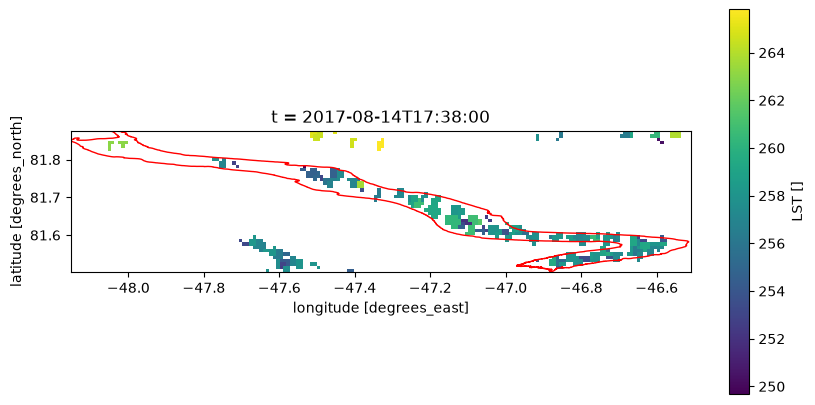

In [40]:
import geopandas as gpd

fig, ax = plt.subplots(figsize=(10, 5))

lst_cloud_free.isel(t=1450).plot(ax=ax)

gpd.GeoSeries([largest_lakes.iloc[0].geometry]).plot(
    ax=ax,
    facecolor='none',
    edgecolor='red'
)

plt.show()